# Лабораторная работа №2
## Предобработка данных

**Датасет:** `tested.csv`

План работы:
1. Импорт библиотек
2. Первичный анализ данных
3. Обработка пропусков
4. Кодирование категориальных признаков
5. Масштабирование данных
6. Проверка результатов и сохранение
7. Вывод


## 1. Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler

`pandas` используется для работы с таблицей, `matplotlib` — для построения графиков,  
`Path` — для поиска файла, `StandardScaler` — для масштабирования числовых признаков.

## 2. Первичный анализ данных

In [2]:
# Ищем tested.csv рядом с notebook или в папке lab-02
csv_path = Path("tested.csv")
if not csv_path.exists():
    csv_path = Path("lab-02") / "tested.csv"

data = pd.read_csv(csv_path)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
print("Размер датасета:", data.shape)
print()
print("Типы данных:")
print(data.dtypes)

Размер датасета: (418, 12)

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [4]:
missing = data.isnull().sum()
missing = missing[missing > 0]

print("Количество пропусков:")
print(missing)

Количество пропусков:
Age       86
Fare       1
Cabin    327
dtype: int64


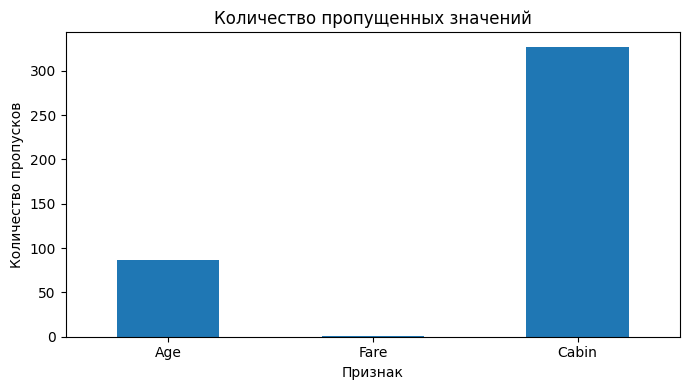

In [5]:
# График количества пропущенных значений
plt.figure(figsize=(7, 4))
missing.plot(kind="bar")
plt.title("Количество пропущенных значений")
plt.xlabel("Признак")
plt.ylabel("Количество пропусков")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

График показывает, что пропуски есть в `Age`, `Fare` и `Cabin`.  
Больше всего пропусков содержится в `Cabin`, поэтому этот признак требует отдельного подхода.

## 3. Обработка пропусков

In [6]:
# Age: заполняем медианой внутри групп Sex + Pclass
data["Age"] = data["Age"].fillna(
    data.groupby(["Sex", "Pclass"])["Age"].transform("median")
)

# Fare: заполняем медианой внутри класса пассажира
data["Fare"] = data["Fare"].fillna(
    data.groupby("Pclass")["Fare"].transform("median")
)

# Cabin: сохраняем только информацию о наличии каюты
data["HasCabin"] = data["Cabin"].notna().astype(int)

# Исходный Cabin больше не нужен
data = data.drop(columns=["Cabin"])

print(data[["Age", "Fare", "HasCabin"]].isnull().sum())

Age         0
Fare        0
HasCabin    0
dtype: int64


- Для `Age` используется медиана пассажиров того же пола и класса.
- Для `Fare` используется медиана внутри соответствующего класса.
- Для `Cabin` создаётся бинарный признак `HasCabin`: `1` — каюта указана, `0` — каюта неизвестна.

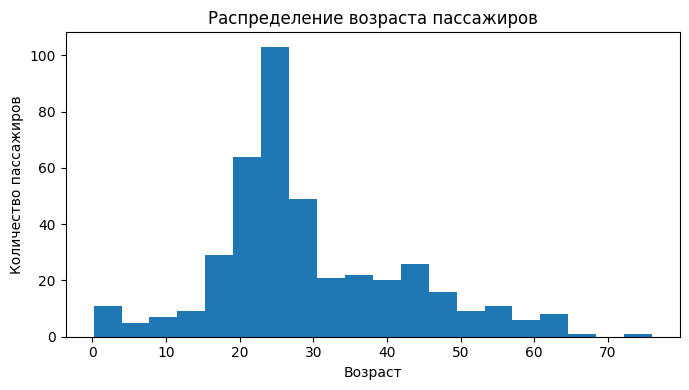

In [7]:
# Распределение возраста после заполнения пропусков
plt.figure(figsize=(7, 4))
plt.hist(data["Age"], bins=20)
plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.tight_layout()
plt.show()

После заполнения пропусков можно увидеть распределение возраста пассажиров.  
Большая часть наблюдений сосредоточена в диапазоне молодых и средневозрастных пассажиров.

## 4. Кодирование категориальных признаков

In [8]:
# Целевая переменная
y = data["Survived"]

# Удаляем целевой признак и признаки, которые не будем использовать
X = data.drop(
    columns=["Survived", "PassengerId", "Name", "Ticket"]
)

# Pclass по смыслу является категорией
X["Pclass"] = X["Pclass"].astype(str)

# One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked", "Pclass"],
    dtype=int
)

X.head()

,Age,SibSp,Parch,Fare,HasCabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,34.5,0,0,7.8292,0,0,1,0,1,0,0,0,1
1,47.0,1,0,7.0000,0,1,0,0,0,1,0,0,1
2,62.0,0,0,9.6875,0,0,1,0,1,0,0,1,0
3,27.0,0,0,8.6625,0,0,1,0,0,1,0,0,1
4,22.0,1,1,12.2875,0,1,0,0,0,1,0,0,1


`pd.get_dummies()` выполняет One-Hot Encoding.  
Каждая категория преобразуется в отдельный столбец из `0` и `1`.

Например, вместо одного признака `Sex` появляются `Sex_female` и `Sex_male`.

## 5. Масштабирование данных

In [9]:
scale_cols = ["Age", "Fare", "SibSp", "Parch"]

print("До масштабирования:")
display(X[scale_cols].head())

scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

print("После масштабирования:")
display(X[scale_cols].head())

До масштабирования:


,Age,Fare,SibSp,Parch
0,34.5,7.8292,0,0
1,47.0,7.0000,1,0
2,62.0,9.6875,0,0
3,27.0,8.6625,0,0
4,22.0,12.2875,1,1


После масштабирования:


,Age,Fare,SibSp,Parch
0,0.399451,-0.497071,-0.499470,-0.400248
1,1.359273,-0.511934,0.616992,-0.400248
2,2.511059,-0.463762,-0.499470,-0.400248
3,-0.176442,-0.482135,-0.499470,-0.400248
4,-0.560371,-0.417159,0.616992,0.619896


`StandardScaler` приводит числовые признаки к единому масштабу.

Формула:

\[
x_{new} = \frac{x - \bar{x}}{\sigma}
\]

После преобразования среднее значение признака становится близким к `0`,  
а стандартное отклонение — близким к `1`.

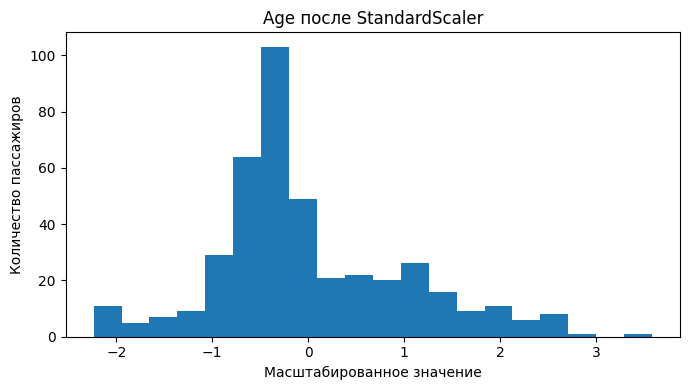

In [10]:
# Распределение Age после масштабирования
plt.figure(figsize=(7, 4))
plt.hist(X["Age"], bins=20)
plt.title("Age после StandardScaler")
plt.xlabel("Масштабированное значение")
plt.ylabel("Количество пассажиров")
plt.tight_layout()
plt.show()

Форма распределения сохраняется, но числовой масштаб изменяется:  
значения теперь выражены относительно среднего и стандартного отклонения.

## 6. Проверка результатов и сохранение

In [11]:
print("Размер итоговой матрицы:", X.shape)
print("Количество пропусков:", X.isnull().sum().sum())

print()
print("Средние значения масштабированных признаков:")
print(X[scale_cols].mean().round(4))

print()
print("Стандартные отклонения:")
print(X[scale_cols].std(ddof=0).round(4))

Размер итоговой матрицы: (418, 13)
Количество пропусков: 0

Средние значения масштабированных признаков:
Age     -0.0
Fare    -0.0
SibSp   -0.0
Parch   -0.0
dtype: float64

Стандартные отклонения:
Age      1.0
Fare     1.0
SibSp    1.0
Parch    1.0
dtype: float64


In [12]:
# Возвращаем целевую переменную и сохраняем результат
processed_data = X.copy()
processed_data["Survived"] = y.values

processed_data.to_csv("tested_processed.csv", index=False)

print("Файл tested_processed.csv сохранён.")
processed_data.head()

Файл tested_processed.csv сохранён.


,Age,SibSp,Parch,Fare,HasCabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,Survived
0,0.399451,-0.499470,-0.400248,-0.497071,0,0,1,0,1,0,0,0,1,0
1,1.359273,0.616992,-0.400248,-0.511934,0,1,0,0,0,1,0,0,1,1
2,2.511059,-0.499470,-0.400248,-0.463762,0,0,1,0,1,0,0,1,0,0
3,-0.176442,-0.499470,-0.400248,-0.482135,0,0,1,0,0,1,0,0,1,0
4,-0.560371,0.616992,0.619896,-0.417159,0,1,0,0,0,1,0,0,1,1


## 7. Вывод

В ходе лабораторной работы:

- проведён первичный анализ данных;
- визуально оценено количество пропусков;
- обработаны пропуски в `Age`, `Fare` и `Cabin`;
- построено распределение возраста;
- категориальные признаки закодированы методом One-Hot Encoding;
- числовые признаки масштабированы с помощью StandardScaler;
- построено распределение масштабированного `Age`;
- проверено отсутствие пропусков;
- итоговый набор сохранён в файл `tested_processed.csv`.

После обработки данные готовы для дальнейшего использования в моделях машинного обучения.